In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "#f8f9fa"
plt.rcParams["axes.edgecolor"] = "#dddddd"
plt.rcParams["grid.color"] = "#d9d9d9"
plt.rcParams["grid.linestyle"] = ":"
plt.rcParams["grid.alpha"] = 0.7

df = pd.read_csv("data/Superstore.csv", encoding="latin1")
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df = df.dropna(subset=["Order Date"])

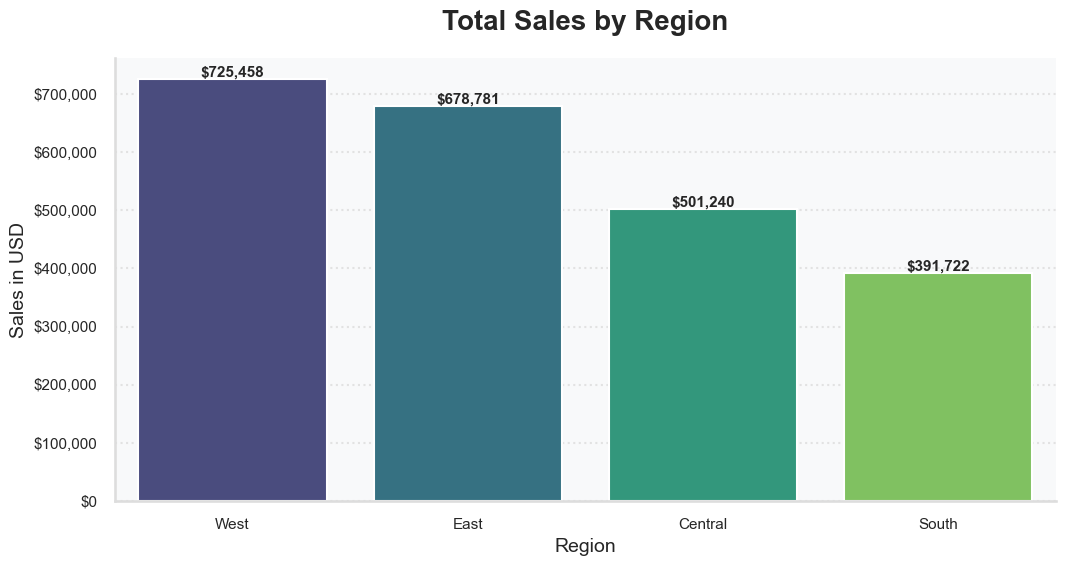

In [3]:
sales_by_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=sales_by_region,
    x="Region",
    y="Sales",
    hue="Region",
    palette="viridis",
    legend=False
)

ax.set_title("Total Sales by Region", pad=20, weight="bold")
ax.set_xlabel("Region")
ax.set_ylabel("Sales in USD")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

for i, value in enumerate(sales_by_region["Sales"]):
    ax.text(i, value + 5000, f"${value:,.0f}", ha="center", weight="bold", fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

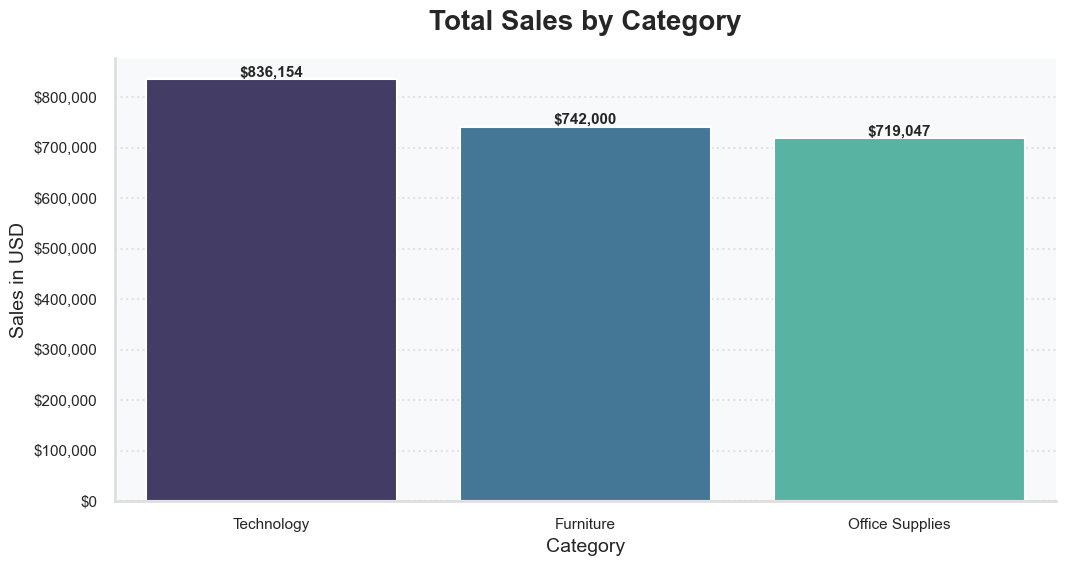

In [4]:
sales_by_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=sales_by_category,
    x="Category",
    y="Sales",
    hue="Category",
    palette="mako",
    legend=False
)

ax.set_title("Total Sales by Category", pad=20, weight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Sales in USD")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

for i, value in enumerate(sales_by_category["Sales"]):
    ax.text(i, value + 5000, f"${value:,.0f}", ha="center", weight="bold", fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

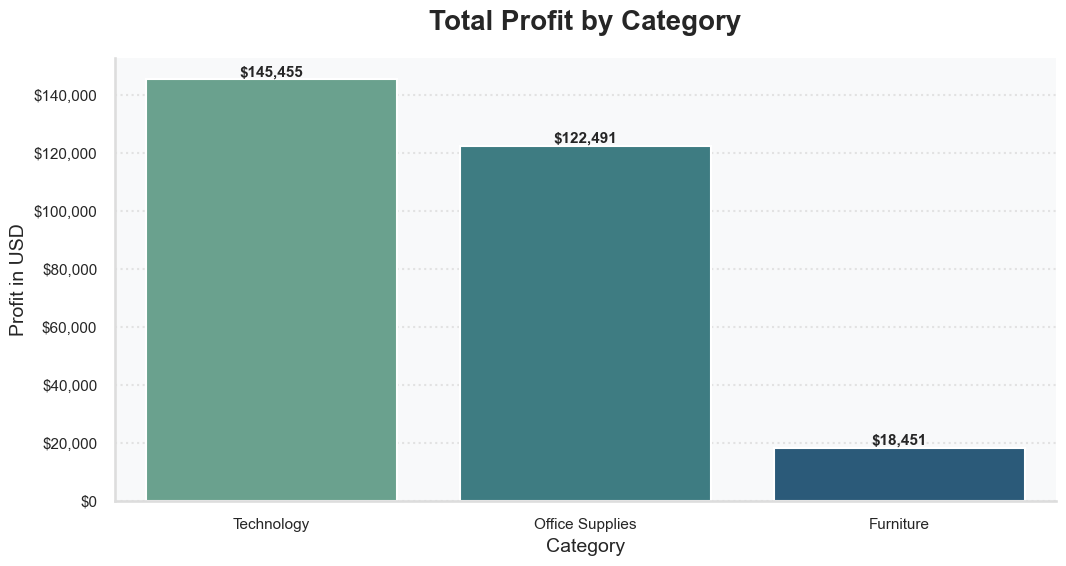

In [5]:
profit_by_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=profit_by_category,
    x="Category",
    y="Profit",
    hue="Category",
    palette="crest",
    legend=False
)

ax.set_title("Total Profit by Category", pad=20, weight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Profit in USD")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

for i, value in enumerate(profit_by_category["Profit"]):
    ax.text(i, value + 1000, f"${value:,.0f}", ha="center", weight="bold", fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

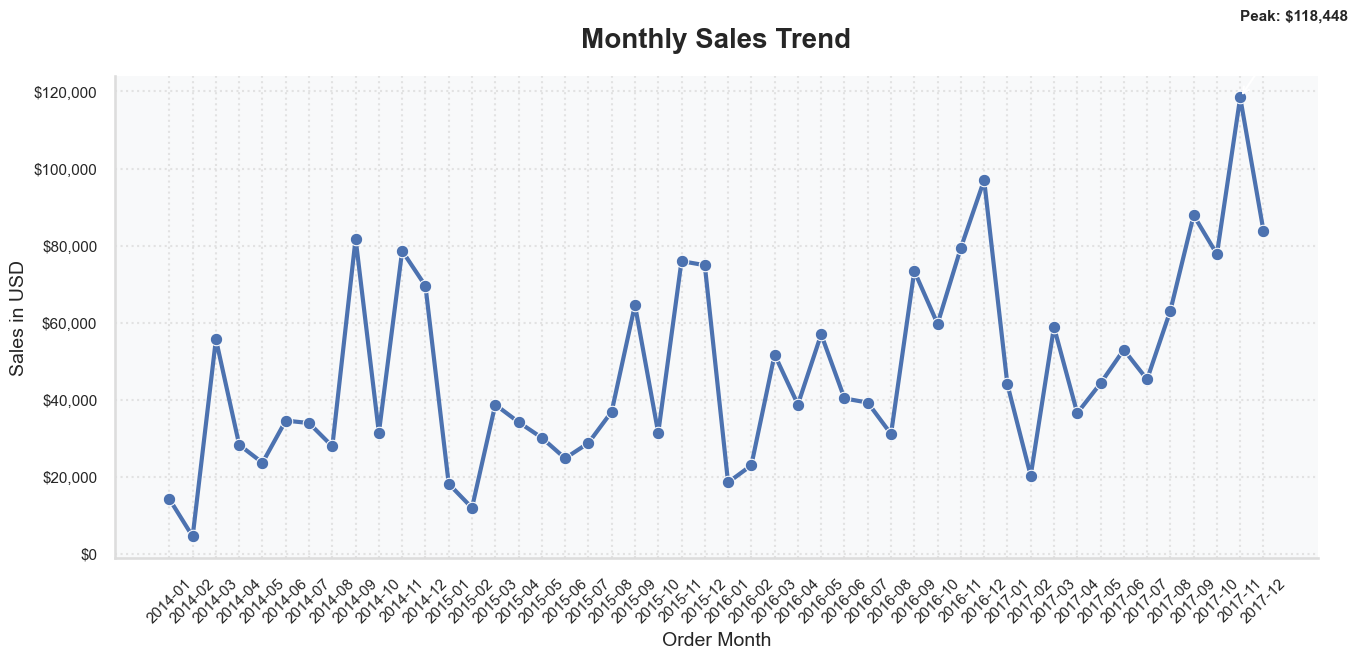

In [6]:
df["Order Month"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("Order Month")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 7))
ax = sns.lineplot(
    data=monthly_sales,
    x="Order Month",
    y="Sales",
    marker="o",
    linewidth=3
)

ax.set_title("Monthly Sales Trend", pad=20, weight="bold")
ax.set_xlabel("Order Month")
ax.set_ylabel("Sales in USD")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=45)

max_idx = monthly_sales["Sales"].idxmax()
max_month = monthly_sales.loc[max_idx, "Order Month"]
max_value = monthly_sales.loc[max_idx, "Sales"]

ax.annotate(
    f"Peak: ${max_value:,.0f}",
    xy=(max_idx, max_value),
    xytext=(max_idx, max_value + 20000),
    arrowprops=dict(arrowstyle="->", lw=1.5),
    fontsize=11,
    weight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

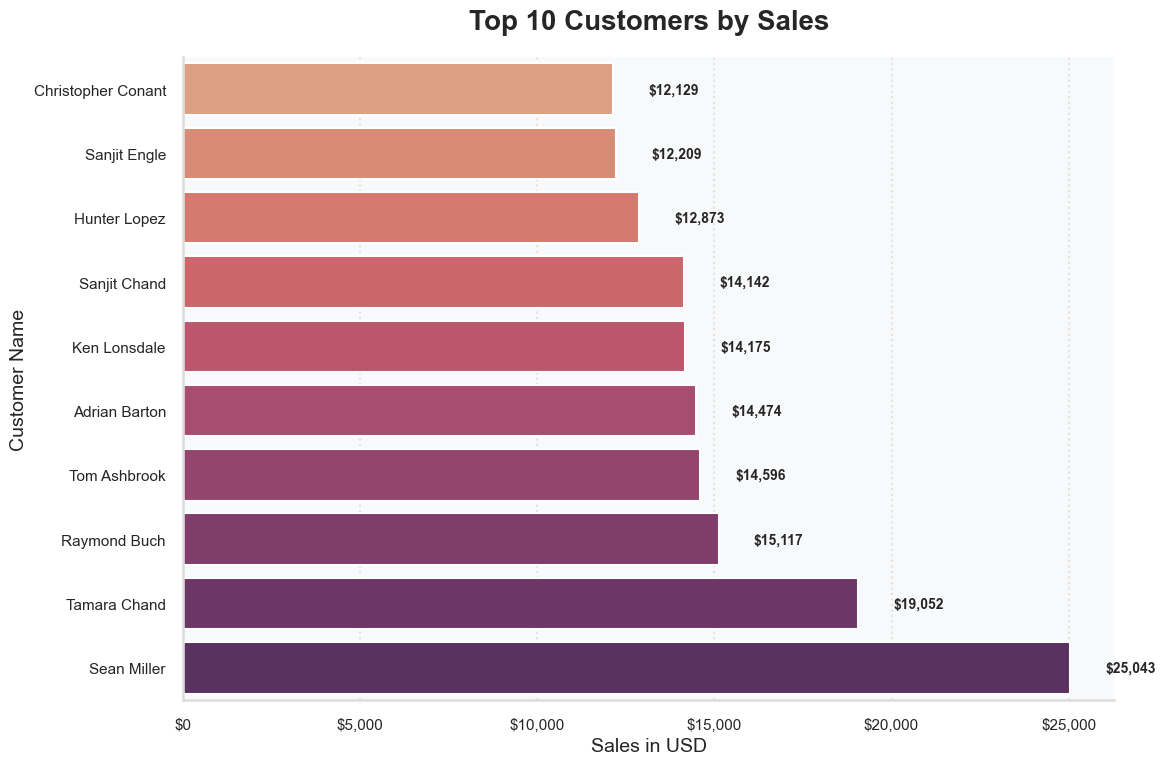

In [7]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=top_customers,
    x="Sales",
    y="Customer Name",
    hue="Customer Name",
    palette="flare",
    legend=False
)

ax.set_title("Top 10 Customers by Sales", pad=20, weight="bold")
ax.set_xlabel("Sales in USD")
ax.set_ylabel("Customer Name")

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

for i, value in enumerate(top_customers["Sales"]):
    ax.text(value + 1000, i, f"${value:,.0f}", va="center", weight="bold", fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

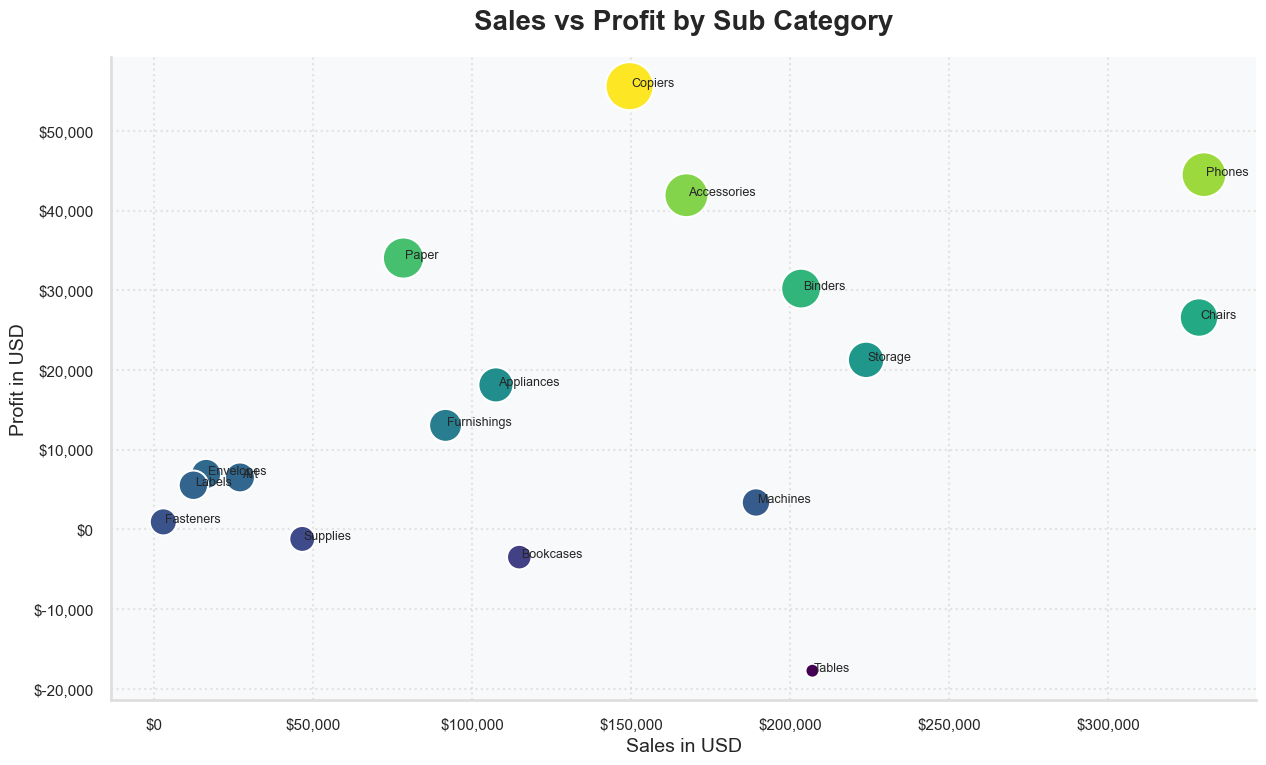

In [8]:
subcat_profit = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(13, 8))
ax = sns.scatterplot(
    data=subcat_profit,
    x="Sales",
    y="Profit",
    size="Profit",
    hue="Profit",
    palette="viridis",
    sizes=(100, 1200),
    legend=False
)

for _, row in subcat_profit.iterrows():
    ax.text(row["Sales"] + 500, row["Profit"], row["Sub-Category"], fontsize=9)

ax.set_title("Sales vs Profit by Sub Category", pad=20, weight="bold")
ax.set_xlabel("Sales in USD")
ax.set_ylabel("Profit in USD")

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

sns.despine()
plt.tight_layout()
plt.show()

### Insight

Sub categories in the high sales and high profit zone are strong performers. High sales with weak profit may need pricing, cost, or product mix review.